slide 1

# **`DATASET INTRODUCTION`**
### Data selection , shape, columns, topic and business context

slide 2
## **`DATASET SELECTION`**
### **Dataset selected :  `Superstore Dataset`**
### **Data Context:** 
##### Faced with growing demand and fierce market competition, an analysis of this superstore's data is being sought to understand its current situation and how, through this analysis, it can improve its present and future. This data repository contains information on product sales, regions, categories, customer segments, and profit/loss for each order.


slide 3
## **`DATASET OVERVIEW`**
### **File:**
#### **Tipo de archivo:   `.csv (standard)`**
####    * **Tamaño : 2.3MB**
####    * **Registros: ≈ 10.000 rows**
####    * **Columns: 21 columns**
### **Description:**
 - The Superstore dataset is a retail transactional dataset containing around 10,000 orders, with detailed information on sales, profit, and customer activity.
######
 - It includes 21 columns covering orders, customers, products, and geographic data, along with key metrics such as sales, quantity, discount, and profit.
######
 - The data spans roughly from 2014 to 2017, enabling time-based analysis of business performance and trends.
### **Columns:**
##### **Selected columns : 15**
- Numerical : row_id , order_id , order_date , customer_id , customer_name , product_id , product_name , sales , quantity , discount , profit

- Categorical : segment , region , category , sub-category

slide 4
## **`DATASET CLEANNIG`**
###
##### 1.- First step - Load the dataset Superstore & import libraries
##### 2.- Second step - Info of data load
##### 3.- Third step - Review the Info and decide on the working dataframe
- 3.1 - Normalize column names
- 3.2 - Cutting working dataframe – 15 selected columns
##### 4.- Fourth step - Review empty , null and invalid values in all columns of work dataframe.
##### FOR ALL COLUMNS
- Deletion of records that have NULL
- Deletion of records that have EMPTY
##### Column QUANTITY 
- Deletion of records that have values >0
##### Column Discount 
- Deletion of records that have values out of interval 0..1
##### Column ORDER DATE
- Deletion of records that don't have correct date format mm/dd/yyyy or m/d/yyyy
### **FINAL RESULT**
`- A DataFrame clean an prepared to work`

## DATA CLEANING


#### 1.- First step - Load the dataset Superstore & import libraries

In [1]:
### IMPORTS

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns
import statsmodels.api as sm
import importlib
import data_cleaning
import warnings
import os
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.figsize':  (11, 5),
    'figure.dpi':      120,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'font.family': 'DejaVu Sans',
    'font.size': 12,
})

importlib.reload(data_cleaning)

from data_cleaning import *
from queue import Empty
from IPython.display import display_html, display
from scipy.stats import chi2_contingency
from scipy.stats.contingency import association

#### 1.- First step - Dataset load

In [2]:
### create df by csv
##main_df = pd.read_csv("datasets/Superstore.csv")    

### create df by csv website
import kagglehub
import os
path = kagglehub.dataset_download("vivek468/superstore-dataset-final") # Download latest version
print("Path to dataset files:", path)
file_path = os.path.join(path, "Sample - Superstore.csv")
main_df = pd.read_csv(file_path,encoding="latin1")

Path to dataset files: /home/gregori/.cache/kagglehub/datasets/vivek468/superstore-dataset-final/versions/1


#### 2.- Second step - Info of data load

In [3]:
info_df(main_df)

**************************************************************************************************** 
*******************************************DATAFRAME INFO******************************************* 
****************************************************************************************************
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


None
**************************************************************************************************** 
****************************************************************************************************

UNIQUE VALUES PER COLUMN:
Row ID           9994
Order ID         5009
Order Date       1237
Ship Date        1334
Ship Mode           4
Customer ID       793
Customer Name     793
Segment             3
Country             1
City              531
State              49
Postal Code       631
Region              4
Product ID       1862
Category            3
Sub-Category       17
Product Name     1850
Sales            5825
Quantity           14
Discount           12
Profit           7287
dtype: int64
**************************************************************************************************** 
****************************************************************************************************


In [4]:
numerical = ['row_id','order_id','order_date','customer_id', 'customer_name', 'product_id', 'product_name','sales', 'quantity', 'discount', 'profit']

categorical = ['segment', 'region', 'category','sub-category']

#### 3.- Third step - Review the Info and decide on the working dataframe

##### 3.1 - Normalize column names

In [5]:
norm_df=normalize_column_names(main_df)



********** NEW COLUMN NAMES NORMALIZED **********
 Index(['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode',
       'customer_id', 'customer_name', 'segment', 'country', 'city', 'state',
       'postal_code', 'region', 'product_id', 'category', 'sub-category',
       'product_name', 'sales', 'quantity', 'discount', 'profit'],
      dtype='object')


##### 3.2 -  Cutting working dataframe

We only use to work these columns : 
(['row_id', 'order_id', 'order_date', 'customer_id', 'customer_name', 'segment', 'region', 'product_id', 'category', 'sub-category','product_name', 'sales', 'quantity', 'discount', 'profit'])
      


In [6]:
### LISTO OF COLUMNS WORK
columns_work=(['row_id', 'order_id', 'order_date', 'customer_id', 'customer_name', 'segment', 'region', 'product_id', 'category', 'sub-category','product_name', 'sales', 'quantity', 'discount', 'profit'])


In [7]:
work1_df=cutting_df(columns_work,norm_df)



************** CUT FROM DATASET PERFORMED OK **************

*************** NEW DATA FRAME COLUMN NAMES ***************
 Index(['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode',
       'customer_id', 'customer_name', 'segment', 'country', 'city', 'state',
       'postal_code', 'region', 'product_id', 'category', 'sub-category',
       'product_name', 'sales', 'quantity', 'discount', 'profit'],
      dtype='object')


#### 4.- Fourth step - Review empty & null values in work dataframe

In [8]:
work2_df=check_nulls_empty(work1_df)



*************** CLEANING EMPY & NULLS ***************


********ROWS ELIMINATED:  0  ********
******ROWS & COLUMNS IN DATAFRAME CLEANED :  (9994, 15)


#### 5.- Fifth step - Review column Quantity for values > 0 in work dataframe

In [9]:
work3_df=remove_non_positive(work2_df,"quantity")


*************** REMOVE VALUES <= 0 ***************

************ COLUMN  quantity  ***************


*****ROWS REMOVED:  0  *****


#### 6.- Sixth step - Review column Discount for values out of 0..1 interval in work dataframe

In [10]:
work4_df=keep_between_0_1(work3_df, "discount")


*************** KEEP VALUES BETWEEN 0 AND 1 ***************


************ COLUMN  discount  ***************


*****ROWS REMOVED:  0  *****


#### 7.- Seventh step - Review column Order_date for invalid date format values

In [11]:
work5_df=keep_valid_dates(work4_df,"order_date")



*************** KEEP VALID DATE FORMAT (M/D/YYYY or MM/DD/YYYY) ***************


************ COLUMN  order_date  ***************


*****ROWS REMOVED:  0  *****


#### 8.- Eighth step - Chane type of column Order_date to date type

In [12]:
work6_df=convert_to_datetime(work5_df, "order_date")
work6_df.dtypes


*************** CONVERT COLUMN TO DATETIME ***************


************ COLUMN  order_date  ***************


*****ROWS REMOVED:  0  *****


row_id                    int64
order_id                 object
order_date       datetime64[ns]
customer_id              object
customer_name            object
segment                  object
region                   object
product_id               object
category                 object
sub-category             object
product_name             object
sales                   float64
quantity                  int64
discount                float64
profit                  float64
dtype: object

Data frame final.


In [13]:
final_df=work6_df
final_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9994 entries, 0 to 9993
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   row_id         9994 non-null   int64         
 1   order_id       9994 non-null   object        
 2   order_date     9994 non-null   datetime64[ns]
 3   customer_id    9994 non-null   object        
 4   customer_name  9994 non-null   object        
 5   segment        9994 non-null   object        
 6   region         9994 non-null   object        
 7   product_id     9994 non-null   object        
 8   category       9994 non-null   object        
 9   sub-category   9994 non-null   object        
 10  product_name   9994 non-null   object        
 11  sales          9994 non-null   float64       
 12  quantity       9994 non-null   int64         
 13  discount       9994 non-null   float64       
 14  profit         9994 non-null   float64       
dtypes: datetime64[ns](1), floa

In [14]:
# Save cleaned dataframe so EDA cells can run independently
final_df.to_csv('final_df_clean.csv', index=False)
print("final_df saved.")

final_df saved.


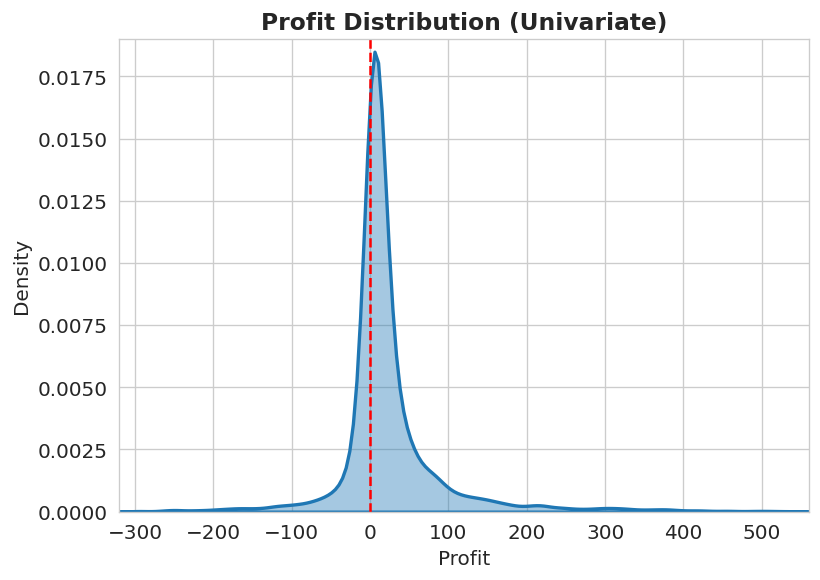

In [15]:


profit_plot = final_df.loc[final_df['profit'].between(-300, 550), 'profit']

sns.set_style("whitegrid")
fig, ax = plt.subplots(figsize=(7, 5))

sns.kdeplot(
            profit_plot,
            fill=True,
            bw_adjust=1.0,
            alpha=0.4,
            linewidth=2,
            )

ax.axvline(0, color='red', linestyle='--')

ax.set_title('Profit Distribution (Univariate)', fontsize=14, fontweight='bold')
ax.set_xlabel('Profit')
ax.set_ylabel('Density')
ax.set_xlim(-320, 560)
ax.set_ylim(0, 0.0190)

plt.tight_layout()
plt.show()

It is a univariate graph in KDE (Kernel Density Estimate) format. The y-axis measures probability density, so the area under the curve equals 1. The x-axis represents profit in dollars per order line, and the y-axis represents density. The red line at x = 0 marks the break-even threshold: everything to the left corresponds to loss-making transactions, and everything to the right corresponds to profitable transactions.

Although the curve appears symmetric, it is not at all in economic terms. The business frequently incurs small losses and infrequently earns large gains. The net positive result is sustained because large purchases numerically compensate for the negative ones.

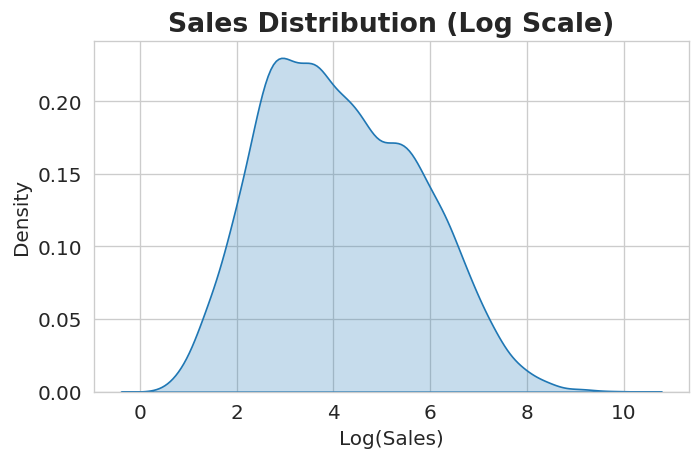

In [16]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.set_style("white")
sns.kdeplot(
            np.log1p(final_df['sales']),
            fill=True,
            bw_adjust=1.0
            )

ax.set_title('Sales Distribution (Log Scale)', fontsize=16, fontweight='bold',fontfamily='DejaVu Sans')
ax.set_xlabel('Log(Sales)')

plt.tight_layout()
plt.show()

This other graph, also a Kernel Density Estimate, focuses on the Sales variable. This time, the x-axis is on a natural logarithmic scale. We do this out of statistical necessity, since on a linear scale the graph would be practically unreadable.

On the x-axis, log(0) corresponds to 1 dollar, log(2) to about 7 dollars, and log(8) to roughly 3,000 dollars. The y-axis again measures probability density. In the graph, the peak is around log(3), which corresponds to about 20 dollars, aligning quite well with the median of 54 dollars.

We can clearly see how the bulk of sales is concentrated in the range of 10–500 dollars. This shows that there are many small tickets and relatively few very large ones, spread across four orders of magnitude.

The key takeaway is that sales volume alone does not predict profitability: a large order with an aggressive discount can generate the biggest loss, while a hundred small, well-priced orders sustain the business margin.

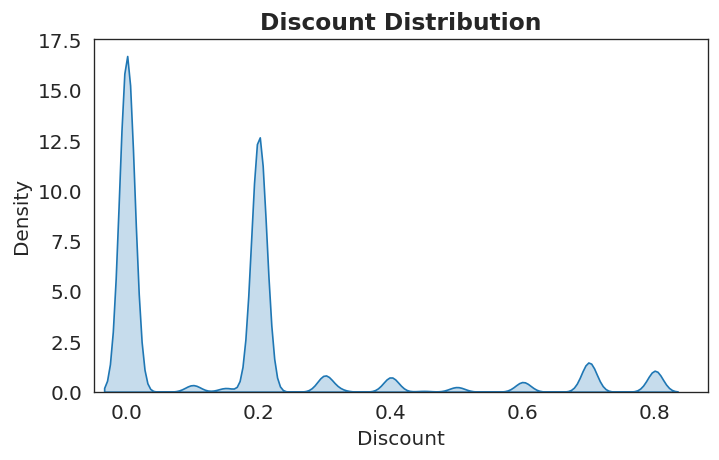

In [17]:
fig, ax = plt.subplots(figsize=(6, 4))

sns.set_style("white")
sns.kdeplot(
            final_df['discount'].dropna(),
            fill=True,
            bw_adjust=0.35
            )

ax.set_title('Discount Distribution', fontsize=14, fontweight='bold',fontfamily='DejaVu Sans')
ax.set_xlabel('Discount')
ax.set_ylabel('Density')
ax.set_xlim(-0.05, 0.88)

plt.tight_layout()
plt.show()

This time, the x-axis represents the applied discount rate, and the y-axis shows probability density. The graph reveals the most important insight of the entire analysis: there is a clear inflection point at exactly 20%.

Below 20%, the business is profitable; above 20%, it systematically loses money. Therefore, we can say that Superstore’s discount policy has a healthy bimodal structure (0% and 20%), but it also carries a small yet destructive right tail where every additional sale erodes margin.

The business insight is straightforward: limiting discounts to 20% would eliminate nearly all loss-making lines in the dataset (reducing them from 1,871 to fewer than 600) and would increase the current net margin of 12.5% to something closer to 18–20%. There is no need to acquire more customers or launch new products — it is enough to stop giving away margin in the 14% of lines that destroy it.

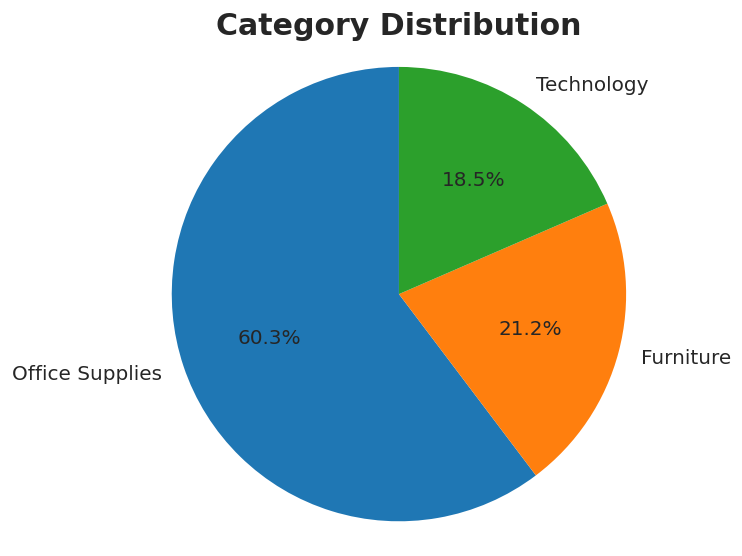

In [18]:
category_counts = final_df['category'].value_counts()
category_counts = category_counts.reindex(['Office Supplies', 'Furniture', 'Technology'])

fig, ax = plt.subplots(figsize=(6, 4.8))

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 12
})

ax.pie(
       category_counts,
       labels=category_counts.index,
       autopct='%1.1f%%',
       startangle = 90,
       textprops={'fontsize': 12},
       wedgeprops={'linewidth': 0}
       )
ax.axis('equal')

ax.set_title(
    'Category Distribution',fontsize=18,fontweight='bold',fontfamily='DejaVu Sans'
)

plt.tight_layout()
plt.show()

Technology: the “small giant” of the business.
It represents only 18.5% of the lines, yet generates 36.4% of sales and more than 50% of total profit. Its size in the pie chart is deceptively small.

Office Supplies: the “inflated volume.”
It appears to be the king by size (60.3%), but contributes only 31.3% of sales and 42.8% of profit. It is a business of loyalty and recurrence, not unit value.

Furniture: the “false friend.”
Its slice in the pie (21.2%) looks very similar to Technology (18.5%) — visually, they seem comparable. But when translated into profit, Furniture contributes only 6.4% of total profit versus 50.8% from Technology. The same visual image hides results that differ by a factor of eight.

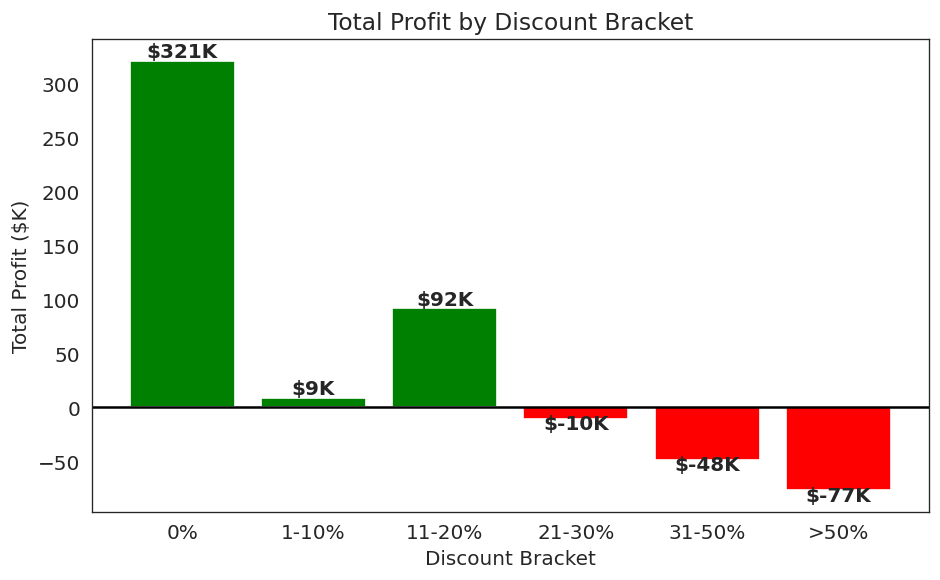

In [19]:
discount_bins = [-0.01, 0.00, 0.10, 0.20, 0.30, 0.50, 1.00]
discount_labels = ['0%', '1-10%', '11-20%', '21-30%', '31-50%', '>50%']

plot_df = final_df.copy()
plot_df['discount_bracket'] = pd.cut(
    plot_df['discount'],
    bins=discount_bins,
    labels=discount_labels,
    include_lowest=True
)

profit_by_discount = plot_df.groupby('discount_bracket')['profit'].sum() / 1000
colors = ['green' if x >= 0 else 'red' for x in profit_by_discount]

sns.set_style("white")
fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    profit_by_discount.index,
    profit_by_discount.values,
    color=colors
)

ax.axhline(0, color='black')

for bar, value in zip(bars, profit_by_discount.values):
    if value >= 0:
        ax.text(bar.get_x() + bar.get_width()/2, value + 3, f'${value:.0f}K',
                ha='center', fontweight='bold')
    else:
        ax.text(bar.get_x() + bar.get_width()/2, value - 10, f'$-{abs(value):.0f}K',
                ha='center', fontweight='bold')

ax.set_title('Total Profit by Discount Bracket', fontsize=14,fontfamily='DejaVu Sans')
ax.set_xlabel('Discount Bracket',fontfamily='DejaVu Sans')
ax.set_ylabel('Total Profit ($K)')

plt.tight_layout()
plt.show()

All the previous charts showed distributions or dispersion. This is the first one that quantifies the real economic impact of each behavior. It transforms a statistical observation (“there is a loss tail”) into an actionable figure (“the >50% segment costs $77,000 in real terms”).

The interpretation is unambiguous: eliminating or sharply limiting high discounts is the highest-impact, lowest-risk lever that Superstore can pull.

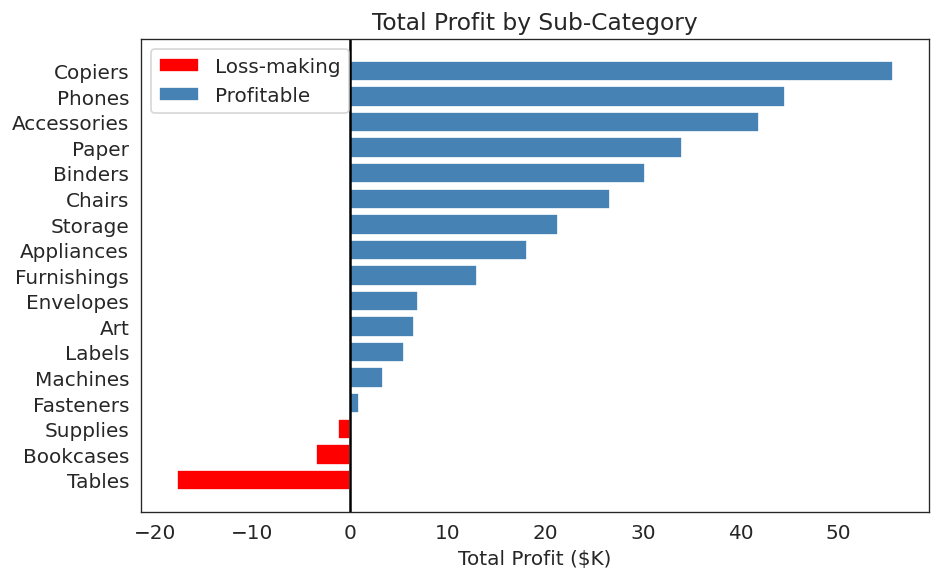

In [20]:
profit_by_subcat = final_df.groupby('sub-category')['profit'].sum().sort_values() / 1000
colors = ['red' if x < 0 else 'steelblue' for x in profit_by_subcat]

sns.set_style("white")
fig, ax = plt.subplots(figsize=(8, 5))

ax.barh(
        profit_by_subcat.index,
        profit_by_subcat.values,
        color=colors
        )

ax.axvline(0, color='black')

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='red', label='Loss-making'),
    Patch(facecolor='steelblue', label='Profitable')
]
ax.legend(handles=legend_elements, loc='upper left')

ax.set_title('Total Profit by Sub-Category', fontsize=14)
ax.set_xlabel('Total Profit ($K)')

plt.tight_layout()
plt.show()

Technically, this is a univariate ranked visualization: a categorical variable (Sub-Category) ordered by a numerical variable (Total Profit).

This chart is the most actionable from an operational standpoint. It precisely quantifies which segments are the business drivers (Copiers, Phones, and Accessories account for 50% of profit) and which are structural value destroyers (Tables, Bookcases, and Supplies drain $22K per year).

It is now clear that Superstore’s problem is not widespread: it is concentrated in two Furniture sub-categories, and the solution can be as specific as limiting discounts on Tables and Bookcases to 20%.

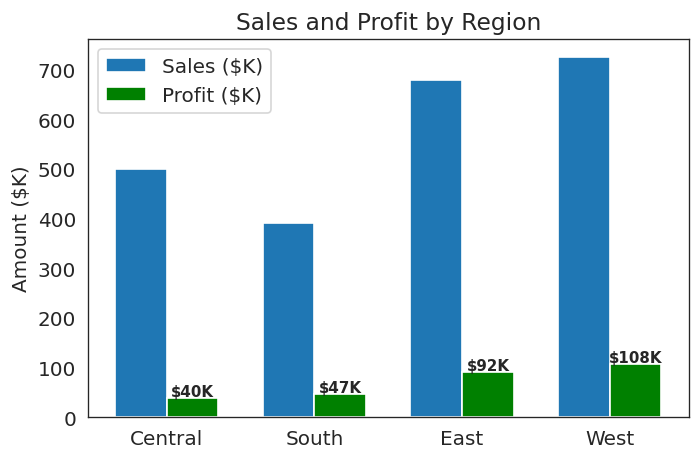

In [21]:
region_summary = final_df.groupby('region')[['sales', 'profit']].sum() / 1000
region_summary = region_summary.reindex(['Central', 'South', 'East', 'West'])

x = np.arange(len(region_summary))
width = 0.35
sns.set_style("white")

fig, ax = plt.subplots(figsize=(6, 4))

bars1 = ax.bar(x - width/2, region_summary['sales'], width, label='Sales ($K)')
bars2 = ax.bar(x + width/2, region_summary['profit'], width, color='green', label='Profit ($K)')

for bar, value in zip(bars2, region_summary['profit']):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        value + 3,
        f'${value:.0f}K',
        ha='center',
        fontweight='bold',
        fontfamily='DejaVu Sans',
        fontsize=9,
    )

ax.set_title('Sales and Profit by Region', fontsize=14, fontfamily='DejaVu Sans')
ax.set_ylabel('Amount ($K)')
ax.set_xticks(x)
ax.set_xticklabels(region_summary.index,fontfamily='DejaVu Sans')
ax.legend(loc='upper left')

plt.tight_layout()
plt.show()

This chart helps us move from saying “high discounts are bad” to “high discounts on Tables and Bookcases sold in Texas and Illinois are the core of the problem.”

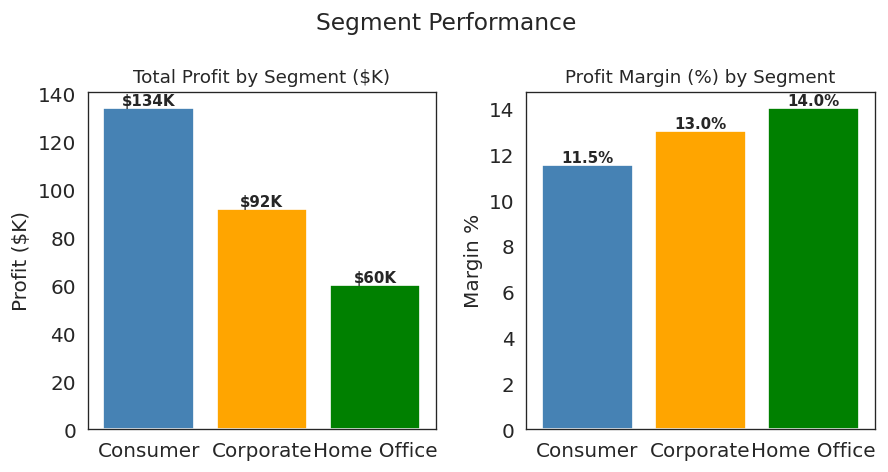

In [22]:
segment_summary = final_df.groupby('segment')[['sales', 'profit']].sum()
segment_summary = segment_summary.reindex(['Consumer', 'Corporate', 'Home Office'])

profit_k = segment_summary['profit'] / 1000
margin_pct = (segment_summary['profit'] / segment_summary['sales']) * 100

sns.set_style("white")

fig, axes = plt.subplots(1, 2, figsize=(7.6, 4))
fig.suptitle('Segment Performance', fontsize=14,fontfamily='DejaVu Sans')

colors = ['steelblue', 'orange', 'green']

bars1 = axes[0].bar(segment_summary.index, profit_k, color=colors)
axes[0].set_title('Total Profit by Segment ($K)', fontsize=11, fontfamily='DejaVu Sans')
axes[0].set_ylabel('Profit ($K)')

for bar, value in zip(bars1, profit_k):
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        value + 1,
        f'${value:.0f}K',
        ha='center',
        fontweight='bold',
        fontfamily='DejaVu Sans',
        fontsize=9,
    )

bars2 = axes[1].bar(segment_summary.index, margin_pct, color=colors)
axes[1].set_title('Profit Margin (%) by Segment', fontsize=11, fontfamily='DejaVu Sans')
axes[1].set_ylabel('Margin %')

for bar, value in zip(bars2, margin_pct):
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        value + 0.1,
        f'{value:.1f}%',
        ha='center',
        fontweight='bold',
        fontfamily='DejaVu Sans',
        fontsize=9,
    )

plt.tight_layout()
plt.show()

This chart adds the customer dimension to the story. Superstore is profitable thanks to Technology, sold without discounts, to Home Office or Corporate customers in the West region. It systematically loses money by selling Furniture (Tables, Bookcases) with discounts above 20% to Consumer customers in the Central region.

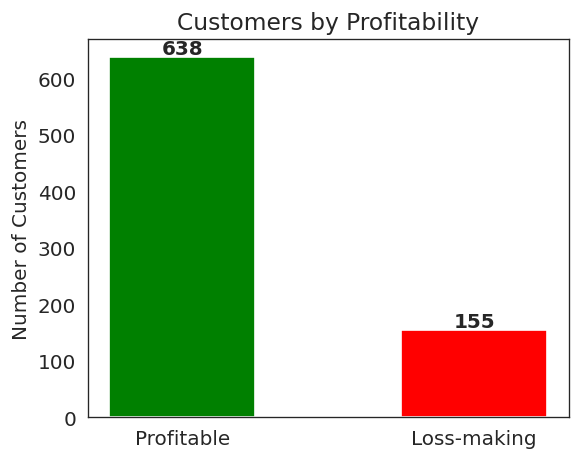

In [23]:
customer_profit = final_df.groupby('customer_name')['profit'].sum()

profitable_count = (customer_profit > 0).sum()
loss_count = (customer_profit < 0).sum()

labels = ['Profitable', 'Loss-making']
values = [profitable_count, loss_count]
colors = ['green', 'red']

sns.set_style("white")

fig, ax = plt.subplots(figsize=(5, 4))

bars = ax.bar(labels, values, color=colors, width=0.5)

for bar, value in zip(bars, values):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        value + 5,
        f'{value}',
        ha='center',
        fontweight='bold',
        fontfamily='DejaVu Sans',
        fontsize=12,
    )

ax.set_title('Customers by Profitability', fontsize=14, fontfamily='DejaVu Sans')
ax.set_ylabel('Number of Customers')

plt.tight_layout()
plt.show()

Here we can see that 1 out of every 5 customers destroys value, accumulating $71K in losses. From this, we can infer that the discount policy should be tied to the customer’s profitability history, not to the product or the channel. Superstore has an identifiable issue with 155 specific Customer IDs that can be named and contacted individually.

CONCLUSIONS:

a) The 20% discount threshold is a hard boundary in the business.
Below 20%, all segments are profitable. Above 20%, 9 out of 10 lines lose money.

b) The concentration of damage is extreme. This is extraordinarily positive from an operational standpoint: the problems are localized, identifiable, and therefore can be addressed with surgical precision. There is no need to reinvent the company.

c) The company has been looking at the wrong metrics: counting orders when it should be measuring margin by customer, by product, and by region.

d) Discounts are not a commercial incentive — they are a structural leakage.